#  **ICT303 - Assignment 2**

**Your name: Kim Andrew Dela Cruz**

**Student ID: 35282436**

**Email: kimandrew712@gmail.com**

In this assignment, you will build and train a deep learning model for solving a problem of your choice.


You are required to:
- Think of a practical problem that you would like to solve. The problem can be related, but not limted to, object detection and recognition from images, text analysis, speech analysis, image unpainting, converting images to artistic painting, action recognition (from images or videos), image to text (i.e., generating textual description for images or videos), or texrt to image (generating images from text) etc.,
- Find an appropriate data set to train and test the model you will develop. Note that the dataset should contain enough data (with groundtruth labels) so that when used for training, the model can generalize well to unseen data.
- Design a neural network that will solve the problem
- Train the neural network on your training data and then evaluate its performance on test data
- Analyze the performance of the network you developed and discuss its limitations.

**What to submit:**
- A colab notebook that describes:
 - The problem you would like to solve **[10 Marks]**
 - The dataset that you will use to train and test the deep learning model that you will develop **[10 marks]**
 - A diagram that describes the architecture of the neural network that you developed **[10 marks]**
 - Performance curves - this is includes the loss curves as well as the accuracy **[10 marks]**
 - A discussion, analysis and justification of the different choices you made and their effect on the performance **[15 marks]**
 - A discussion, analysis of the limitations of your method. You can also show failure cases and try to understand why did it fail on these cases **[15 marks]**

- Source code that runs - this includes both code for training and testing **[30 marks]**

You also need to submit the dataset you used for training and testing, or alternatively provide the code that downloads the data.

Make sure you reference all sources from which you took information.

You are allowed to use existing neural networks (not required to implement them from scratch). But, you must customize the architecture to the problem you want to solve.

**Where to find datasets?**
- [Kaggle competition](https://www.kaggle.com/c/dog-breed-identification) is a good source.
- You can also look at this [wikipedia site[(https://en.wikipedia.org/wiki/List_of_datasets_for_machine-learning_research)

If you are thinking of a specific problem and were unable to find a suitable dataset, please talk to me during the lecture or lab and we will search together.

**Recommended timeline**
- Week 1 of Assignement release: identify 2 or 3 problems of interest, a find dataset for each of the problem and try to understand how to load the data and how it is organised. Discuss it with the UC during the lab session or via email.
- Week 2:
 - Make sure your dataloader works proply and you are able to load the data and structure it in a way that neural networks can use them.
 - Design your network architecture
- Week 3: Network architecture implemented and training and testing done. Evaluate the performance
- Week 4: Finetune the network architecture and the hyperparameters to improve the performance. Write the report for submission.

It is highly recommended that you follow this timeline. The earlier you start training and testing, the more time you will have to finetune your solution and achieve a better performance.


# Problem and Goals

* The problem I chose is to create a movie recommendation system.
* The goal is to create a basic neural collaboration filtering model and train it with a dataset of movie reviews.
* I find this problem interesting and relevant to the real-world because most applications such as streaming services, or even food delivery apps uses some sort of recommendation system to help improve and streamline the user experience, this could be done by means of ruled-based, or machine learning-based recommendation systems. I want to use this problem as an opportunity to explore how machine learning-based recommendation systems work.



# Dataset
* The dataset I used is "Letterboxd Movie Ratings Data" by Sam Learner from Kaggle.com

* It consisted of 3 csv files of which I only used 2, movie_data.csv, and ratings_export.csv
* ratings_export contains the user_id, rating_val, and movie_id.
* movie_data.csv contains movie_id and various movie metadata.

* movie_data.csv contains 285,933 unique values/movies.
* ratings_export.csv contains 11,078,167 unique values/reviews.

* I merged movie_data and ratings_export into one dataframe so I can filter out reviews for unpopular movies.

* After merging and filtering out unpopular movies, my merged dataframe contains around 1.1 million reviews.

* I split the reviews into two parts, for training and for validation to 80/20. Training dataset contains 80% while the validation dataset contains 20%.

* I used the validation dataset as my test dataset too.

dataset - https://www.kaggle.com/datasets/samlearner/letterboxd-movie-ratings-data?

# Movie Recommendation using Neural Collaboration Filtering Model

In [1]:
%load_ext tensorboard
print("tensorboard extension loaded")

tensorboard extension loaded


## import and dependencies

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import tqdm
import os
import shutil
import time
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error

import kagglehub


path = kagglehub.dataset_download("samlearner/letterboxd-movie-ratings-data")

print("Path to dataset files:", path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

Path to dataset files: /home/kim/.cache/kagglehub/datasets/samlearner/letterboxd-movie-ratings-data/versions/6
Device: cuda


# Architecture Design
* I created my model based on the [paper](https://arxiv.org/pdf/1708.05031) on Neural Collaboration Filters proposed by He et al. (2017).
* The paper explores a hybrid model of Neural Collaboration Filter that combines GMF (General Matrix Factorization) and MLP (Multilayer Perceptron).
* The key difference between my modified NCF model Architecture from the  NCF model in the paper is:
  - I added Batch Normalization inside my MLP layers.
  - I used embeddings from nn module of pytorch to map the item and user indices.
  - I dont use sigmoid before returning the output because my recommendation/rating value is Explicit (0-5) and not Implicit (binary, 0 or 1).

## Neural Collaboration Filtering Model Architecture

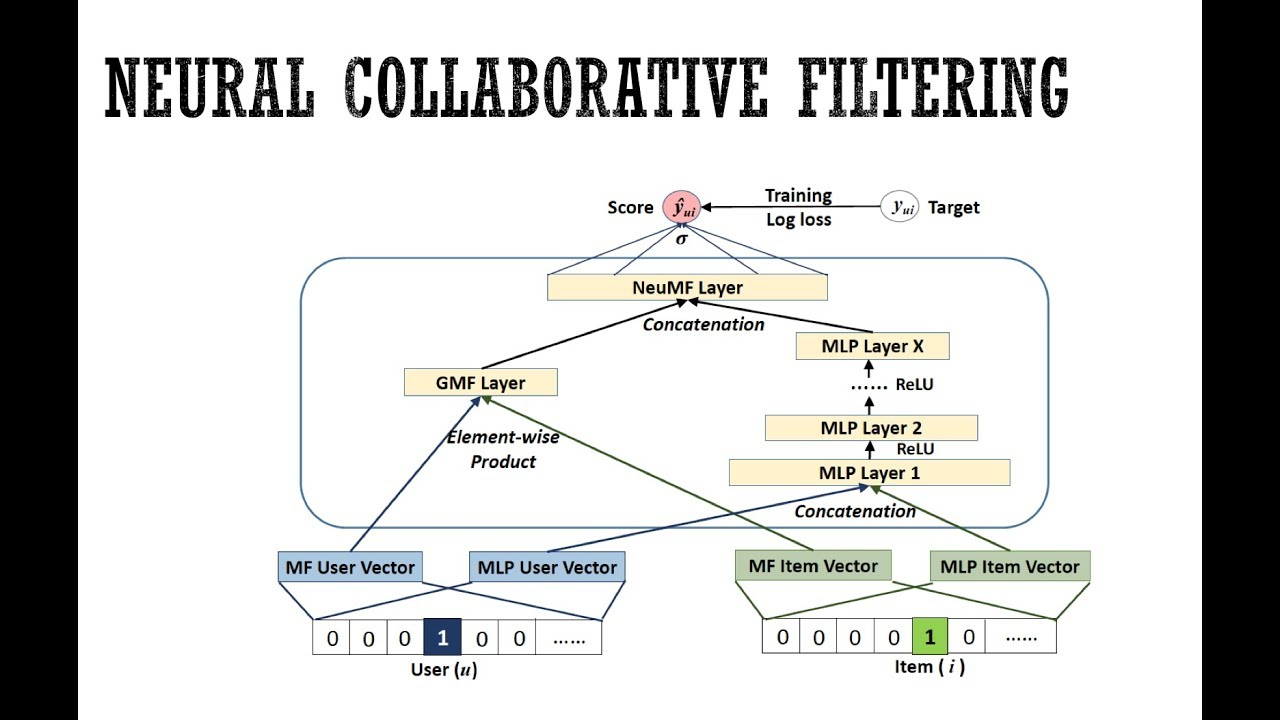

# My implementaion of Neural Matrix Factorization (NeuMF) Nueral Collaboration Filter Model
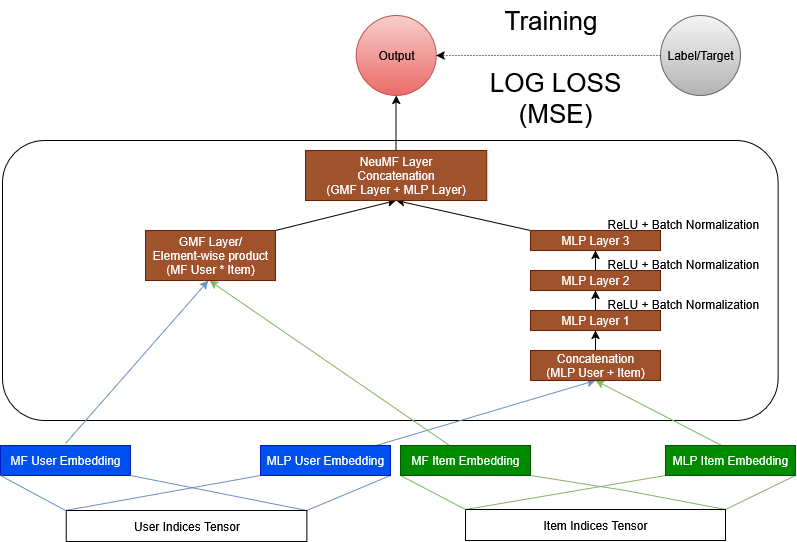

## NCF Model Class


In [4]:
class NCF(nn.Module):
    def __init__(self, user_count, item_count, embedding_size=8, lr=1e-3, optimizer_type="adam"):
        super(NCF, self).__init__()
        self.lr = lr
        self.optimizer_type = optimizer_type

        # Initialize GMF Embeddings
        self.user_embedding_gmf = nn.Embedding(num_embeddings=user_count, embedding_dim=embedding_size)
        self.item_embedding_gmf = nn.Embedding(num_embeddings=item_count, embedding_dim=embedding_size)

        # Initialize MLP Embeddings
        self.user_embedding_mlp = nn.Embedding(num_embeddings=user_count, embedding_dim=embedding_size)
        self.item_embedding_mlp = nn.Embedding(num_embeddings=item_count, embedding_dim=embedding_size)

        # MLP Layer
        self.mlp_layers = nn.Sequential(
            # First Layer
            nn.Linear(in_features=embedding_size * 2, out_features=64),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),
            # Second Layer
            nn.Linear(in_features=64, out_features=32),
            nn.BatchNorm1d(num_features=32),
            nn.ReLU(),
            # Third Layer
            nn.Linear(in_features=32, out_features=16),
            nn.BatchNorm1d(num_features=16),
            nn.ReLU()
        )

        # Final prediction layer
        self.output_layer = nn.Linear(in_features=embedding_size + 16, out_features=1)  # GMF (embedding_size) + MLP output (16)

    def forward(self, user_indices, item_indices):
        # Map user/item indices into embedding layers for GMF Layer
        gmf_user = self.user_embedding_gmf(user_indices)
        gmf_item = self.item_embedding_gmf(item_indices)

        # Map user/item indices into embedding layers for MLP Layer
        mlp_user = self.user_embedding_mlp(user_indices)
        mlp_item = self.item_embedding_mlp(item_indices)

        # Perform element-wise product on GMF embeddings (user x items)
        gmf_output = gmf_user * gmf_item

        # MLP concatenate.
        mlp_cat = torch.cat(tensors=[mlp_user, mlp_item], dim=-1)

        #MLP output.
        mlp_output = self.mlp_layers(mlp_cat)

        # NeuMF Layer (GMF x MLP)
        NeuMF = torch.cat(tensors=[gmf_output, mlp_output], dim=-1)

        # Final prediction
        output = self.output_layer(NeuMF).squeeze(-1)

        return output

    def loss(self, y_hat, y):
        return nn.MSELoss()(y_hat, y)

    def configure_optimizers(self):
        if self.optimizer_type == "adam":
            return optim.Adam(self.parameters(), lr=self.lr)
        elif self.optimizer_type == "sgd":
            return optim.SGD(self.parameters(), lr=self.lr)
        else:
            return optim.Adam(self.parameters(), lr=self.lr)

# Breakdown of NCF model

---



## Initialize embeddings and Map the user/item indices tensor into their embeddings

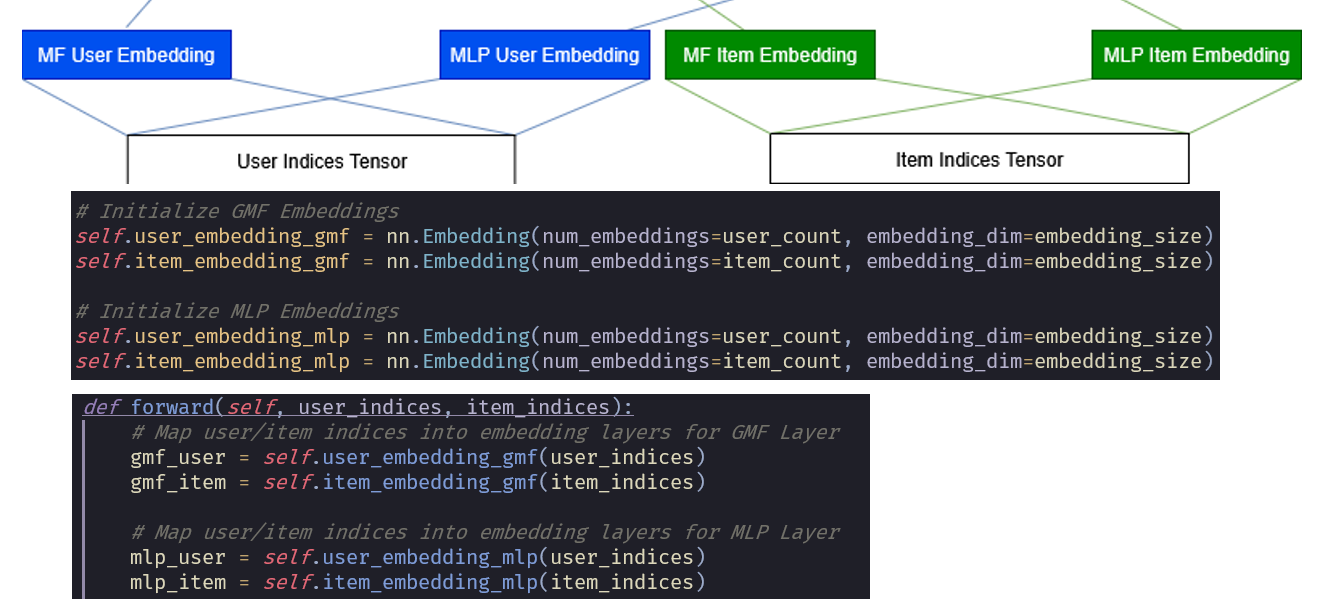

# Concatenate the MLP User and Item Embeddings before passing it to mlp_layers()
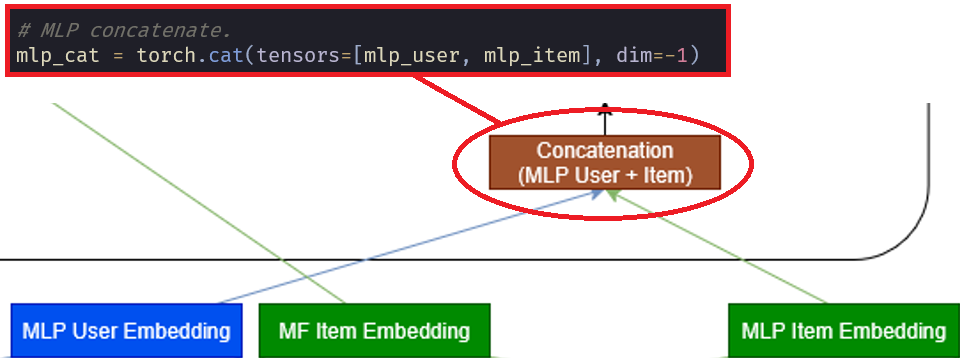

## Pass the concatenated MLP embeddings to the MLP Layers
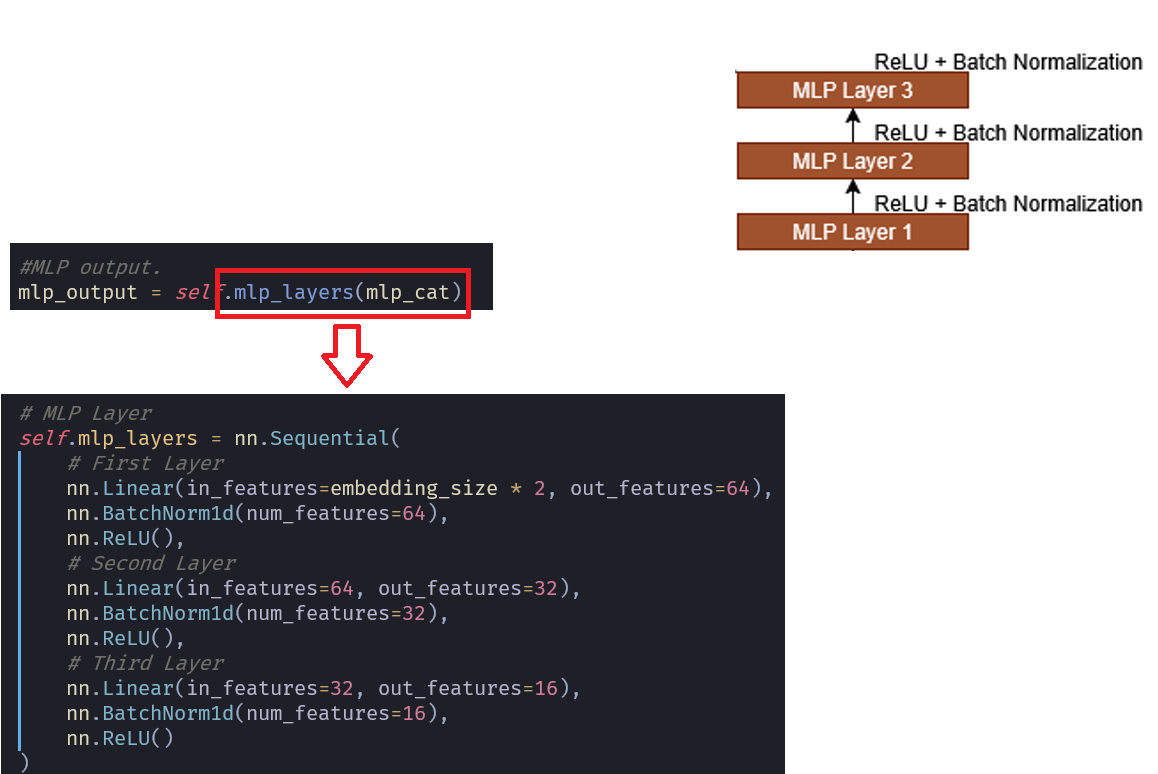


## Multiply the MF user embedding with the MF item embedding to get the element-wise product.
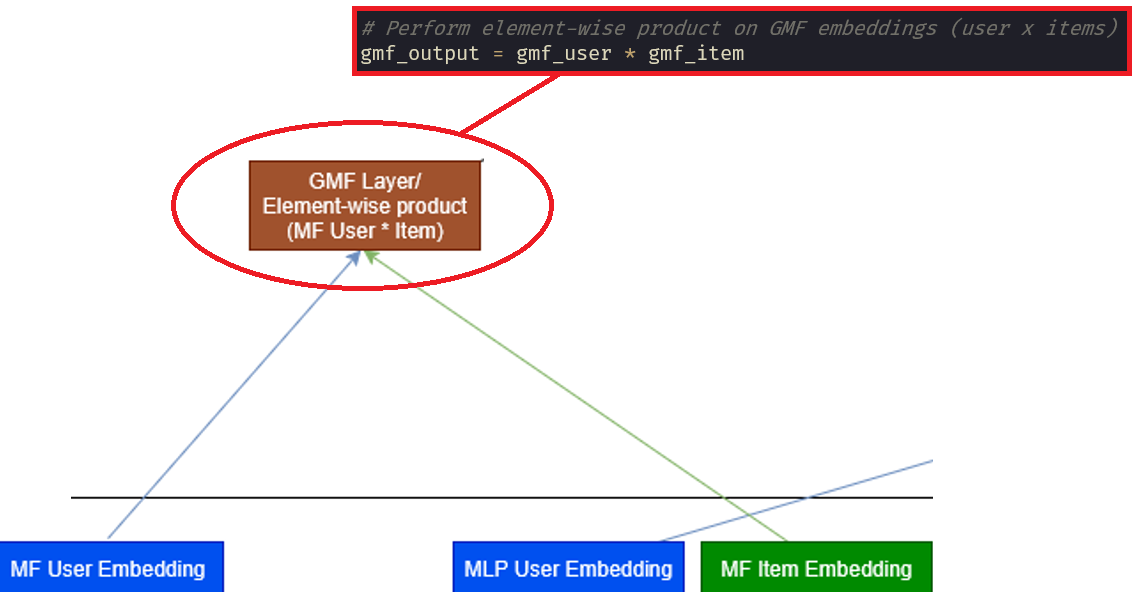


## Concatenate General Matrix Factorization (GMF) Layer and MLP Layer, This will be the NeuMF Layer
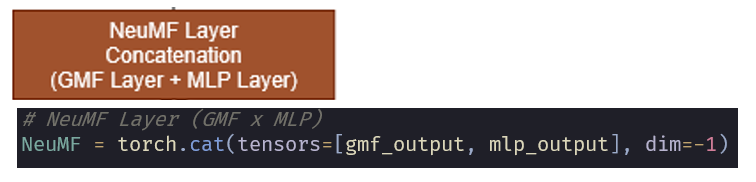

## Finally, Pass the NeuMF Layer to a final output layer.
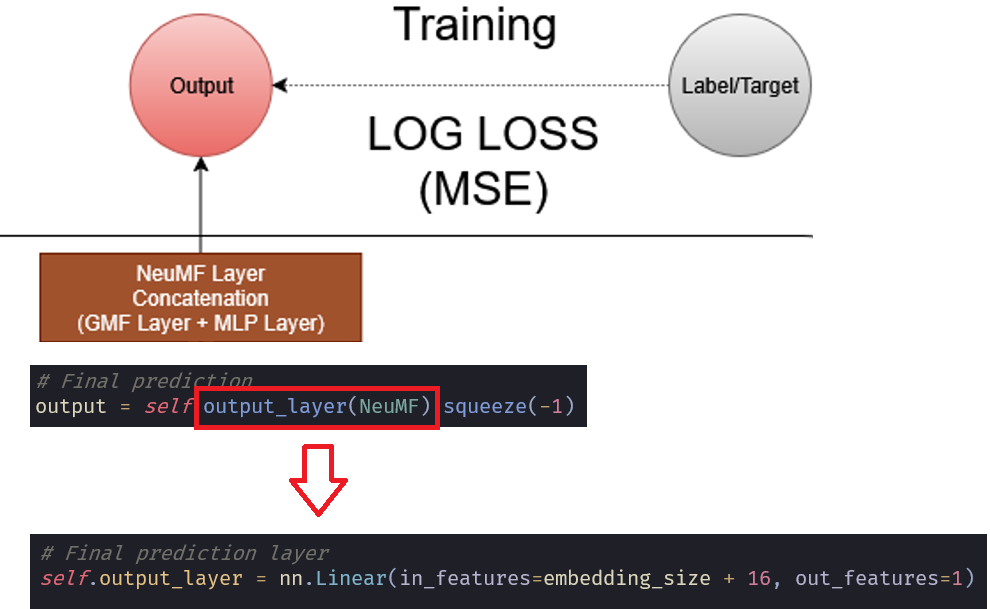



---



# Trainer Class

In [27]:
class Trainer:

  def __init__(self, tb, n_epochs = 3):
    self.max_epochs = n_epochs
    self.writer = tb  # the tensorboard instance
    return

  def fit(self, model, data, validation_data):
    self.data = data
    self.validation_data = validation_data
    self.optimizer = model.configure_optimizers()
    self.model     = model

    for epoch in range(self.max_epochs):
      print(f"\nEpoch {epoch + 1}/{self.max_epochs}")
      self.fit_epoch()
      self.validate_epoch()

      # Tensorboard Logging
      self.writer.add_scalar("Training Loss", self.avg_training_loss, epoch)
      self.writer.add_scalar("Validation Loss", self.avg_val_loss, epoch)

    print("Training process has finished")

  def fit_epoch(self):

    self.model.train()
    current_loss = 0.0
    self.avg_training_loss = 0.0

    for i, data in enumerate(tqdm(self.data, desc="Training")):
      user, item, target = data
      user, item, target = user.to(device), item.to(device), target.to(device)

      self.optimizer.zero_grad()

      outputs = self.model(user, item)

      loss = self.model.loss(outputs, target)

      loss.backward()

      self.optimizer.step()

      current_loss += loss.item()

      self.avg_training_loss += loss.item()

      if i % 500 == 499:
          print('Loss after mini-batch %5d: %.3f' %
                (i + 1, current_loss / 500))
          current_loss = 0.0

    # The average training loss
    self.avg_training_loss = self.avg_training_loss / i
    print(f"Training Loss (avg): {self.avg_training_loss:.4f}")

  def validate_epoch(self):

    self.model.eval()
    total_loss = 0.0
    self.avg_val_loss = 0.0

    with torch.no_grad():

      for i, data in enumerate(self.validation_data):
        user, item, target = data
        user, item, target = user.to(device), item.to(device), target.to(device)

        outputs = self.model(user, item)

        loss = self.model.loss(outputs, target)

        total_loss += loss.item()

      # The average training loss
      self.avg_val_loss = total_loss / (i + 1)
      print(f"Validation Loss (avg): {self.avg_val_loss:.4f}")

# Dataloader class

In [6]:
class DataManager:
    def __init__(self, dataframe):
        self.data = dataframe.copy()
        self.data["label"] = self.data["rating_val"] / 2.0  # Normalized from 0-10 to 0–5.0

        # Map user and item IDs to indices
        self.user_indices = {u: i for i, u in enumerate(self.data["user_id"].unique())}
        self.item_indices = {m: i for i, m in enumerate(self.data["movie_id"].unique())}

        # Mapping user/movie ids to a unique index.
        self.data["user"] = self.data["user_id"].map(self.user_indices)
        self.data["item"] = self.data["movie_id"].map(self.item_indices)

        self.user_count = len(self.user_indices)
        self.item_count = len(self.item_indices)
        self.data = self.data[["user", "item", "label"]]


        users = torch.tensor(self.data["user"].values, dtype=torch.long)
        items = torch.tensor(self.data["item"].values, dtype=torch.long)
        labels = torch.tensor(self.data["label"].values, dtype=torch.float32)

        dataset = TensorDataset(users, items, labels)

        val_size = int(len(dataset) * 0.2)
        train_size = len(dataset) - val_size

        self.train_dataset, self.val_dataset = random_split(dataset, [train_size, val_size])

    def get_dataloaders(self):
        return self.train_dataset, self.val_dataset


# Main

## Data Extraction and Filtering

In [8]:
# Extract csv to dataframe
movie_df = pd.read_csv(os.path.join(path,'movie_data.csv'), engine='python', on_bad_lines='skip')
ratings_df = pd.read_csv(os.path.join(path,'ratings_export.csv'), engine='python',on_bad_lines='skip')

# Merge movie metadata into the rating dataframe
merged_data_df = pd.merge(ratings_df, movie_df, on='movie_id')

# Filter Data, Remove unpopular movies
filtered_reviews = merged_data_df[merged_data_df['popularity'] > 50]

## Hyperparameters

In [49]:
embedding_dim=32
lr=0.001
batch_size=4096
n_epochs=20

## Load Dataset

In [14]:
data = DataManager(filtered_reviews)

train_dataset,val_dataset = data.get_dataloaders()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size,
                          num_workers=4, pin_memory=True)


Done


## Training

In [50]:
# Model
model = NCF(user_count=data.user_count, item_count=data.item_count, embedding_size=embedding_dim, lr=lr)
model.to(device)

# Delete Tensorboard data if it exist
if os.path.exists('runs/ncf_model'):
  shutil.rmtree('runs/ncf_model')
writer = SummaryWriter(log_dir="runs/ncf_model")

# Train
trainer = Trainer(tb=writer, n_epochs=n_epochs)
trainer.fit(model, train_loader, val_loader)


Epoch 1/20


Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 247/247 [00:04<00:00, 54.25it/s]

Training Loss (avg): 5.9868


Validation Loss (avg): 1.3172

Epoch 2/20


Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 247/247 [00:04<00:00, 50.78it/s]

...

Training Loss (avg): 0.5324


Validation Loss (avg): 0.5522

Epoch 20/20


Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 247/247 [00:05<00:00, 45.73it/s]

Training Loss (avg): 0.5298


Validation Loss (avg): 0.5514
Training process has finished


## Evaluation

### Evaluation Classes

In [42]:
def evaluate_rmse(model, dataloader, device):
    model.eval()
    mse_loss = nn.MSELoss()
    total_loss = 0.0
    count = 0
    start = time.time()

    with torch.no_grad():
        for users, items, labels in dataloader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            predictions = model(users, items)
            loss = mse_loss(predictions, labels)
            total_loss += loss.item() * labels.size(0)
            count += labels.size(0)

    end = time.time()
    rmse = (total_loss / count) ** 0.5
    print(f"RMSE: {rmse:.4f} - Inference Time: {end - start:.2f}s")

def evaluate_mae(model, dataloader, device):
    model.eval()
    total_absolute_error = 0.0
    count = 0
    start = time.time()

    with torch.no_grad():
        for users, items, labels in dataloader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            predictions = model(users, items)

            # Compute absolute error for the batch and sum
            absolute_error = torch.abs(predictions - labels).sum().item()
            total_absolute_error += absolute_error
            count += labels.size(0)

    end = time.time()
    mae = total_absolute_error / count
    print(f"MAE: {mae:.4f} - Inference Time: {end - start:.2f}s")


def recommend_movies(
    model,
    data,
    user_name: str,
    dataframe,  # full ratings DataFrame (with movie titles, etc.)
    k: int = 10
):
    model.eval()

    # Retrieve Rating from User
    user_ratings = dataframe[dataframe["user_id"] == user_name]
    if user_ratings.empty:
        print(f"User '{user_name}' not found or has no ratings.")
        return

    # Retrieve and print top-k movies by User
    top_rated = user_ratings.sort_values(by="rating_val", ascending=False).head(k)
    print(f"\nTop {k} movies rated by '{user_name}':")
    for i, row in enumerate(top_rated.itertuples(index=False), 1):
        print(f"{i}. {row.movie_title} — Rating: {row.rating_val}")

    # Check if  user exists in the user index map
    if user_name not in data.user_indices:
        print(f"User '{user_name}' not found in index mapping.")
        return

    user_idx = data.user_indices[user_name]

    # Retrieve all movie_ids rated by this user
    rated_movie_ids = set(user_ratings["movie_id"])

    # Retrieve unseen movie_ids and their corresponding indices
    unseen_movies = [
        (item_idx, movie_id)
        for movie_id, item_idx in data.item_indices.items()
        if movie_id not in rated_movie_ids
    ]

    if not unseen_movies:
        print("No recommendations available.")
        return

    # 6. Predict ratings for unseen movies
    user_tensor = torch.tensor([user_idx] * len(unseen_movies), dtype=torch.long).to(device)
    item_tensor = torch.tensor([item_idx for item_idx, _ in unseen_movies], dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_tensor, item_tensor).squeeze()

    # Retrieve top-k movie_ids based on predicted ratings
    top_k_indices = torch.topk(predictions, k).indices.cpu().numpy()
    top_k_movie_ids = [unseen_movies[i][1] for i in top_k_indices]

    # Retrieve and Convert movie_id to movie_title
    movie_dict = dict(zip(dataframe["movie_id"], dataframe["movie_title"]))

    # Display recommendations
    print(f"\n{k} Movie Recommendations for '{user_name}':")
    for rank, movie_id in enumerate(top_k_movie_ids, 1):
        title = movie_dict.get(movie_id, "Unknown Title")
        print(f"{rank}. {title}")



### RMSE Root Mean Square Error Test (Lower Value = Better)

In [53]:
evaluate_rmse(model, val_loader, device)


RMSE: 0.7426 - Inference Time: 1.08s


### MAE Mean Absoulte Error Test

In [35]:
evaluate_mae(model, val_loader, device)

MAE: 0.5782 - Inference Time: 1.02s


### View user_id's

In [36]:
user_review_counts = (
    filtered_reviews.groupby("user_id")["movie_id"]
    .count()
    .reset_index(name="num_reviews") # type: ignore
    .sort_values(by="num_reviews", ascending=False)
)
user_review_counts.style.set_table_attributes(
    'style="display:inline-block; height:200px; overflow:auto;"'
)


,user_id,num_reviews
3074,imzzzy,984
6516,tburnett217,726
3381,jeremy_crabb,673
493,asdfbatman,672
1367,coleturner,665
2601,ghettominibar,658
64,aaronblocke,650
1401,connorcarey,645
4407,matt_thomas10,641
1118,cathal89,632


### Test Recommendation

In [52]:
user = input("Enter a user id:" )

recommend_movies(
    model=model,
    data=data,
    user_name=user,
    dataframe=filtered_reviews,
    k=10
)

Enter a user id:houndy

Top 10 movies rated by 'houndy':
1. A Silent Voice — Rating: 9
2. Drive — Rating: 8
3. Star Wars: The Last Jedi — Rating: 8

10 Movie Recommendations for 'houndy':
1. Morbius
2. Inglourious Basterds
3. The Legacy of Chucky
4. Evangelion: 3.0+1.0 Thrice Upon a Time
5. The Shawshank Redemption
6. The Lion King
7. TXT (TOMORROW X TOGETHER) 'Eternally'
8. The Lord of the Rings: The Return of the King
9. Spirited Away
10. The Lord of the Rings: The Fellowship of the Ring


In [51]:
%tensorboard --logdir runs --port 6009

Reusing TensorBoard on port 6009 (pid 11042), started 0:22:29 ago. (Use '!kill 11042' to kill it.)

# Observations



1.Observations of NCF Model: Optimizer=Adam, Epoch=20, lr=.0001, embdding_dim=32


*   2 hours to train
*   RMSE: 0.7582 - Inference Time: 6.29s
* Overfitting at Epoch 12
* Results of deathproof: very niche recommendations but to be fair, he has 2.3k reviews (no life)
* Results of ericanders: a few similar recommendations to deathproof, will look into this, probably something wrong with the model.
* Found out ericanders also have no life (1.5k reviews)
* Results of houndy: user with only 55 reviews. Most of his/her top movies are animation films, recommendations are niche but very different from the previous users

* users with many reviews = similar recommendations. I believe this is due to people watching the same popular movies.
* a lot of the recommendations are non-english movies and not well known

* Does not recommend relevant items for users with few ratings


2. Observations of NCF Model: Optimizer=Adam, Epoch=10, lr=.0001, embdding_dim=32  
* 3.3min to Train
* RMSE: 0.7682 - Inference Time: 13.12s
* No overfitting
* Important: I merged ratings_export and movie_data into one dataframe. Also filtered the dataframe, removing all unpopular movies (popularity = < 50, Lord of the rings is 80-90 in comparison).
  - unfiltered: 11 million reviews
  - filtered (by popular/popularity>50): 1.1 million reviews
* Results of deathproof: Much better. The model recommended popular media which he haven't watched yet. He/she likes sci-fi and adventure, most of the recommendation for him/her are sci-fi/Fiction and adventure. Based on his recommended movies, he/she likes artsy
* Results of houndy: Also better. From 55 movies, he/she only has 3 movies that wasnt wiped from the data cleaning. His/her top movie is an animation film, and most of his/her recommendations were also animation. For only 3 reviews, his/her recommendation looked great.

3. Observations of NCF Model: Optimizer=Adam, Epoch=20, lr=.0001, embdding_dim=32, Added Batch normalization in mlp layer
* 9min to Train
* RMSE: 0.7384 - Inference Time: 6.17s
* Validation Loss Curve looks better than NCF without batch normalization
* Results: Similar results as the NCF without batch normalization

4. Obersvations of NCF Model: Optimizer=Adam, Epoch=10, lr=.0001, embdding_dim=32, Added Batch normalization in mlp layer, Refactored class in charge of data management

* Refactored my Dataloader class -> DataManager Class, instead of using custom Dataset (from torch.utils), I used TensorDataset(also from torch.utils).
* Huge improvement in training time. only take less than 5 sec per epoch.
* Same results

5. Obeservations of 0.001 Learning Rate vs 0.0001 Learning Rate



* 0.0001 Learning Rate
---

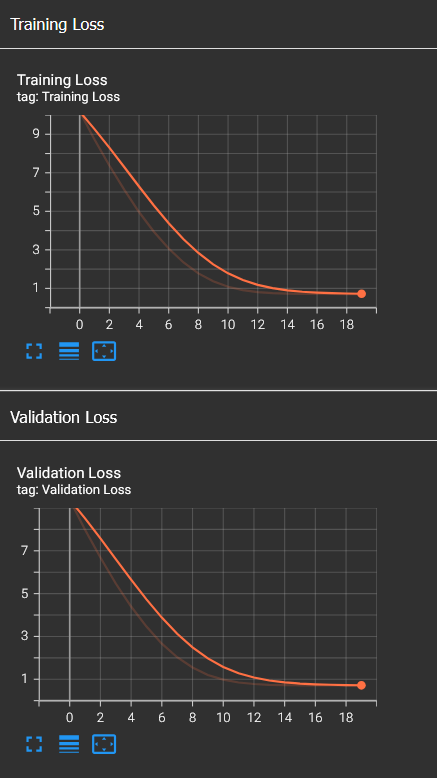




* 0.001 Learning Rate
---
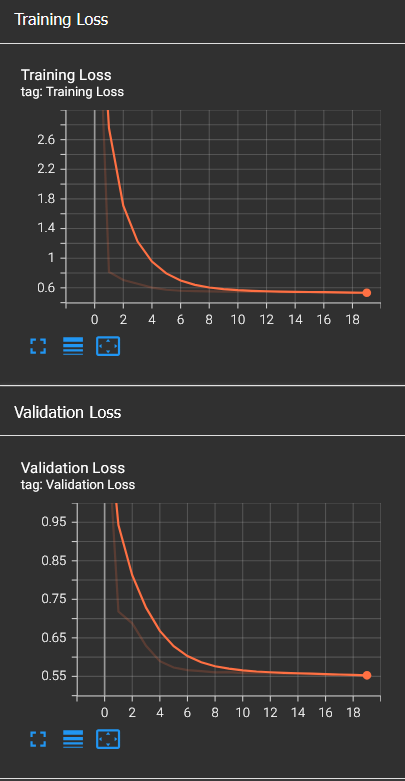

*  0.001 Trains better With no signs of overfitting.
* Training and Validation Loss of 0.001 Drops significantly faster than 0.0001

# Limitations


* My current model is a basic Neural Collaboration Filter model. It is strictly collabarative filtering and does not filter content (user preference)
* It can only recommends movies based on other users likeness. It does not have the ability to personalize according to the user's genre/director/studio bias (content-based filtering).

## Failure Cases
* Users with few reviews, will result to similar recommendations
* Users that watched all of the popular movies will not get any recommendations for hidden gems, because dataset is hardcoded to only have popular movies.

## Potential Improvements:
* instead of a Basic Neural Collaboration Filter model, I can use a hybrid recommendation system, that combines content-based filtering and neural collaboration filtering. This will allow to recommend movies based on user preference as well as other users likeness.

# Design Choices
* For my chosen Hyperparemeters:
  - 0.001 Learning Rate is stable and the best performing during training.
  - 4096 batch size is sufficient, I tried 8192 but I didnt see any improvements from 4096.
  - 4096 and 8192 batchsize, barely touched my GPU usage. During training, it only used 3gb of vram and 30% GPU usage.
  - MLP Layers with batch normalization also improved performance
  - Im using the Adam optimizer because I had a slight overfitting when I used the sgd optimizer
  - For my training loss I chose MSE because it is commonly used for Neural Collaboration Filter model with explicit ratings.
  - For my number of Epochs, I chose 20, because there are no signs of overfitting.

# Reference


*   Learner, S. (n.d.). Letterboxd movie ratings data . Kaggle. https://www.kaggle.com/datasets/samlearner/letterboxd-movie-ratings-data - Dataset
*   He, X., Liao, L., Zhang, H., Nie, L., Hu, X., & Chua, T. S. (2017). Neural collaborative filtering. arXiv preprint arXiv:1708.05031. https://arxiv.org/abs/1708.05031 - paper on NCF and Diagram of Architecture Model
